## Параметры

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root_scalar, least_squares
from scipy.special import roots_hermite
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Каталог для сохранения PNG (dynare_images/ рядом с ноутбуком).
REPO_ROOT = Path(os.getcwd()).resolve()
IMG_DIR = REPO_ROOT / 'dynare_images'
IMG_DIR.mkdir(exist_ok=True)
DYNARE_MAT = REPO_ROOT / 'dynare_irf.mat'

# ---------- Параметры (согласовано с Dynare) ----------
alpha   = 0.33
betta   = 0.95
delta   = 0.025
theta   = 1.25      # CRRA
psi     = 0.75      # disutility of labor exponent
phi     = 5.0
rho     = 0.7
sigma   = 0.2       # как в Dynare: sig_tfp = 0.2

def compute_steady_state():
    R = 1.0 / betta + delta - 1.0
    W = ((1.0 - alpha)**(1.0 - alpha) * alpha**alpha / R**alpha) ** (1.0 / (1.0 - alpha))
    K2L = (W / R) * alpha / (1.0 - alpha)
    C2L = K2L**alpha - delta * K2L
    L = ((W / phi) / C2L**theta) ** (1.0 / (psi + theta))
    K = K2L * L
    C = C2L * L
    Y = K**alpha * L**(1.0 - alpha)
    I = delta * K
    return K, L, C, Y, I, R, W

K_ss, L_ss, C_ss, Y_ss, I_ss, R_ss, W_ss = compute_steady_state()
print(f"SS: K={K_ss:.6f}, C={C_ss:.6f}, L={L_ss:.6f}, Y={Y_ss:.6f}, I={I_ss:.6f}")

# ---------- Границы сетки ----------
# При sigma_tfp = 0.2 безусловный std(z) ≈ 0.28, шок exp(z) даёт TFP в диапазоне
# ~[0.5, 2.0] => для перенесения за пределы сетки требуется широкий box по K.
K_min, K_max = 0.2 * K_ss, 2.5 * K_ss
std_z_uncond = sigma / np.sqrt(1.0 - rho**2)
z_min, z_max = -3.0 * std_z_uncond, 3.0 * std_z_uncond

n_K = 12
n_Z = 8
n_hermite = 9


SS: K=3.114430, C=0.654800, L=0.359216, Y=0.732661, I=0.077861


## 2. Узлы Чебышёва и базис

In [2]:
def chebyshev_nodes(n, a, b):
    x = np.cos((2.0*np.arange(1, n+1) - 1.0) * np.pi / (2.0*n))
    return 0.5*(a+b) + 0.5*(b-a)*x

def chebyshev_polynomials(x, deg, a, b):
    x = np.atleast_1d(x)
    y = 2.0 * (x - a) / (b - a) - 1.0
    y = np.clip(y, -1.0, 1.0)   # защита от выхода из диапазона
    T = np.zeros((len(x), deg))
    T[:, 0] = 1.0
    if deg > 1:
        T[:, 1] = y
    for k in range(2, deg):
        T[:, k] = 2.0 * y * T[:, k-1] - T[:, k-2]
    return T

K_nodes = np.sort(chebyshev_nodes(n_K, K_min, K_max))
z_nodes = np.sort(chebyshev_nodes(n_Z, z_min, z_max))

T_K = chebyshev_polynomials(K_nodes, n_K, K_min, K_max)
T_z = chebyshev_polynomials(z_nodes, n_Z, z_min, z_max)

## Функции модели

In [3]:
def labor_from_KC(K, C, z):
    if K <= 0 or C <= 1e-12:
        return np.nan
    tfp = np.exp(z)
    rhs = (1.0 - alpha) * tfp * (K ** alpha) / (phi * (C ** theta))
    if rhs <= 0:
        return np.nan
    L = rhs ** (1.0 / (psi + alpha))
    if not np.isfinite(L) or L <= 0:
        return np.nan
    return L

def production(K, L, z):
    return np.exp(z) * (K ** alpha) * (L ** (1.0 - alpha))

def rental_rate(K, L, z):
    Y = production(K, L, z)
    return alpha * Y / K

def wage(K, L, z):
    Y = production(K, L, z)
    return (1.0 - alpha) * Y / L

## 4. Начальное приближение

In [4]:
def solve_C_stationary_given_Kz(K, z):
    def res(C):
        L = labor_from_KC(K, C, z)
        if np.isnan(L):
            return 1e8
        Y = production(K, L, z)
        return Y - C - delta * K

    upper = max(2.5 * Y_ss, 2.5 * C_ss, 1.0)
    try:
        sol = root_scalar(res, bracket=[1e-8, upper], method='brentq')
        if sol.converged and np.isfinite(sol.root) and sol.root > 0:
            return sol.root
    except Exception:
        pass
    return C_ss

def numerical_elasticity():
    eps = 1e-4

    C_plus_k = solve_C_stationary_given_Kz(K_ss * (1.0 + eps), 0.0)
    C_minus_k = solve_C_stationary_given_Kz(K_ss * (1.0 - eps), 0.0)
    den_k = np.log(K_ss * (1.0 + eps)) - np.log(K_ss * (1.0 - eps))
    eta_c_k = (np.log(C_plus_k) - np.log(C_minus_k)) / den_k

    C_plus_z = solve_C_stationary_given_Kz(K_ss, +eps)
    C_minus_z = solve_C_stationary_given_Kz(K_ss, -eps)
    eta_c_z = (np.log(C_plus_z) - np.log(C_minus_z)) / (2.0 * eps)

    if (not np.isfinite(eta_c_k)) or abs(eta_c_k) > 10:
        eta_c_k = 0.25
    if (not np.isfinite(eta_c_z)) or abs(eta_c_z) > 10:
        eta_c_z = 1.00

    return eta_c_k, eta_c_z

eta_c_k, eta_c_z = numerical_elasticity()
print(f"eta_c_k = {eta_c_k:.6f}, eta_c_z = {eta_c_z:.6f}")

def initial_C(K, z):
    expo = eta_c_k * np.log(max(K, 1e-12) / K_ss) + eta_c_z * z
    expo = np.clip(expo, -50.0, 50.0)
    val = C_ss * np.exp(expo)
    return np.clip(val, 1e-8, 10.0 * C_ss)

C_init_grid = np.zeros((n_K, n_Z))
for i, K in enumerate(K_nodes):
    for j, z in enumerate(z_nodes):
        C_init_grid[i, j] = initial_C(K, z)

# Чебышёвская подгонка к C_init_grid: vec_col(C) = (T_z ⊗ T_K) · vec_col(theta).
# lstsq возвращает vec_col(theta), поэтому распаковка — order='F'.
A = np.kron(T_z, T_K)
c_vec = C_init_grid.T.flatten()
theta_init_flat, _, _, _ = lstsq(A, c_vec, rcond=None)

# Проверка корректности раскладки коэффициентов.
theta_init_mat = theta_init_flat.reshape((n_K, n_Z), order='F')
recover = T_K @ theta_init_mat @ T_z.T
fit_err = np.linalg.norm(recover - C_init_grid) / max(np.linalg.norm(C_init_grid), 1e-12)
print(f"Init Chebyshev fit relative error = {fit_err:.3e}")


eta_c_k = 0.256682, eta_c_z = 0.970751
Init Chebyshev fit relative error = 1.474e-15


## 5. Гаусс–Эрмит и правильное уравнение Эйлера

In [5]:
herm_nodes, herm_weights = roots_hermite(n_hermite)

def gh_expectation(func, z_current):
    mean = rho * z_current
    std = sigma
    z_next_vals = mean + np.sqrt(2.0) * std * herm_nodes
    weights = herm_weights / np.sqrt(np.pi)
    vals = np.array([func(z_next) for z_next in z_next_vals])
    return np.sum(weights * vals)

## 6. Аппроксимация политики C(K,z)

In [6]:
def C_from_theta(K, z, theta_mat):
    K_eval = np.clip(K, K_min, K_max)
    z_eval = np.clip(z, z_min, z_max)

    T_K_pt = chebyshev_polynomials(np.array([K_eval]), n_K, K_min, K_max).flatten()
    T_z_pt = chebyshev_polynomials(np.array([z_eval]), n_Z, z_min, z_max).flatten()

    C = T_K_pt @ theta_mat @ T_z_pt
    return max(C, 1e-8)

## 7. Исправленная невязка Эйлера

In [7]:
def euler_residuals(theta_flat, K_grid_1d, z_grid_1d, theta_old_mat=None,
                    penalty=1e3, debug=False):
    """Эйлер-невязки на коллокационной сетке.

    Если theta_old_mat=None — используется текущая theta для C_next (классическая
    one-shot коллокация). Если задан — фиксируется политика для C_next, чтобы
    делать time-iteration (внешний цикл обновления theta_old_mat).
    """
    theta_mat = theta_flat.reshape((n_K, n_Z), order='F')
    theta_for_next = theta_old_mat if theta_old_mat is not None else theta_mat
    residuals = []

    for i, K in enumerate(K_grid_1d):
        for j, z in enumerate(z_grid_1d):
            C = C_from_theta(K, z, theta_mat)
            L = labor_from_KC(K, C, z)

            if np.isnan(L) or L <= 0:
                residuals.append(penalty)
                continue

            Y = production(K, L, z)
            I = Y - C
            K_next = (1.0 - delta) * K + I

            if (not np.isfinite(K_next)) or (K_next <= 1e-10):
                residuals.append(penalty)
                continue

            def integrand(z_next):
                # C_from_theta сама экстраполирует за границу через clip,
                # но если K_next реально вылетает далеко — правильнее штрафовать.
                C_next = C_from_theta(K_next, z_next, theta_for_next)
                L_next = labor_from_KC(K_next, C_next, z_next)
                if np.isnan(L_next) or L_next <= 0:
                    # «честный» штраф через большое значение: подавляет такой узел,
                    # но не ноль — оптимизатор должен видеть градиент.
                    return penalty
                R_next = rental_rate(K_next, L_next, z_next)
                val = (C / C_next) ** theta * (R_next + 1.0 - delta)
                if not np.isfinite(val):
                    return penalty
                return val

            rhs = betta * gh_expectation(integrand, z)
            residuals.append(1.0 - rhs)

            if debug and i == len(K_grid_1d)//2 and j == len(z_grid_1d)//2:
                print(f"K={K:.4f}, z={z:.4f}, C={C:.4f}, "
                      f"K_next={K_next:.4f}, resid={1.0-rhs:.4e}")

    return np.array(residuals)


## 8. Оптимизация

In [8]:
print("Проверка начальной невязки...")
init_res = euler_residuals(theta_init_flat, K_nodes, z_nodes)
init_ssr = np.sum(init_res**2)
print(f"SSR initial = {init_ssr:.6e}")
print(f"Max abs residual initial = {np.max(np.abs(init_res)):.6e}")

# --- Time-iteration с ускорением Андерсона по θ.
# T(θ_old) — оператор обновления политики (внутренний trf-шаг). У базового
# fixed-point замедление вблизи аттрактора, у Anderson — гораздо быстрее.
def fixed_point_step(theta_old_flat, theta_curr_flat):
    theta_old_mat = theta_old_flat.reshape((n_K, n_Z), order='F')
    sol = least_squares(
        lambda th: euler_residuals(th, K_nodes, z_nodes, theta_old_mat=theta_old_mat),
        theta_curr_flat,
        method='trf',
        bounds=bounds,
        x_scale='jac',
        max_nfev=20000,
        ftol=1e-12,
        xtol=1e-12,
        gtol=1e-12,
        verbose=0,
    )
    return sol.x, sol

n_params = n_K * n_Z
bounds = (-1e3 * np.ones(n_params), 1e3 * np.ones(n_params))

theta_curr_flat = theta_init_flat.copy()
theta_old_flat = theta_init_flat.copy()

ti_tol = 1e-8
ti_max = 80
m_anderson = 5            # глубина истории Андерсона
beta_mix = 1.0            # фактор смешивания (1.0 = чистый Andersen)
hist_F = []               # history of F(theta) = T(theta) - theta
hist_X = []               # history of theta

print("Time-iteration (Чебышёв коллокация + trf, Anderson m=5):")
prev_diff = np.inf
for it in range(1, ti_max + 1):
    theta_new_flat, sol = fixed_point_step(theta_old_flat, theta_curr_flat)
    F = theta_new_flat - theta_old_flat
    diff = np.linalg.norm(F) / max(np.linalg.norm(theta_old_flat), 1e-12)
    inner_max = np.max(np.abs(sol.fun))

    if it == 1:
        # первый шаг — обычный fixed-point update
        theta_next_flat = theta_new_flat
    else:
        hist_F.append(F)
        hist_X.append(theta_old_flat.copy())
        if len(hist_F) > m_anderson:
            hist_F.pop(0)
            hist_X.pop(0)

        # Решаем lstsq по разностям F (формула Anderson type-II).
        if len(hist_F) >= 2:
            dF = np.array(hist_F[1:]) - np.array(hist_F[:-1])
            dX = np.array(hist_X[1:]) - np.array(hist_X[:-1])
            try:
                gamma, *_ = np.linalg.lstsq(dF.T, F, rcond=None)
                theta_next_flat = (theta_old_flat + beta_mix * F
                                   - (dX.T + beta_mix * dF.T) @ gamma)
            except np.linalg.LinAlgError:
                theta_next_flat = theta_new_flat
        else:
            theta_next_flat = theta_new_flat

    theta_curr_flat = theta_next_flat.copy()
    theta_old_flat = theta_next_flat.copy()

    print(f"  iter {it:2d}:  ||T(θ)-θ||/||θ|| = {diff:.3e}, "
          f"inner max|resid| = {inner_max:.3e}, nfev={sol.nfev}")
    if diff < ti_tol:
        print(f"Time-iteration сошёлся: ||Δθ||/||θ|| = {diff:.3e} < {ti_tol}")
        break
    prev_diff = diff
else:
    print("Time-iteration: достигнут предел итераций.")

theta_opt = theta_old_flat.reshape((n_K, n_Z), order='F')
final_res = euler_residuals(theta_curr_flat, K_nodes, z_nodes)
final_ssr = np.sum(final_res ** 2)
print(f"\nFinal SSR = {final_ssr:.6e}")
print(f"Max abs residual = {np.max(np.abs(final_res)):.6e}")
print(f"Improvement ratio (final/init) = {final_ssr / max(init_ssr, 1e-12):.4e}")

C_at_ss = C_from_theta(K_ss, 0.0, theta_opt)
print(f"C(K_ss, 0) = {C_at_ss:.6f}, C_ss = {C_ss:.6f}, "
      f"rel diff = {(C_at_ss - C_ss) / C_ss:.3e}")

_ = euler_residuals(theta_curr_flat, K_nodes, z_nodes, debug=True)


Проверка начальной невязки...
SSR initial = 8.655052e+00
Max abs residual initial = 8.420756e-01
Time-iteration (Чебышёв коллокация + trf, Anderson m=5):


  iter  1:  ||T(θ)-θ||/||θ|| = 2.217e-01, inner max|resid| = 1.332e-15, nfev=7


  iter  2:  ||T(θ)-θ||/||θ|| = 1.515e-01, inner max|resid| = 1.998e-15, nfev=6


  iter  3:  ||T(θ)-θ||/||θ|| = 1.052e-01, inner max|resid| = 1.110e-15, nfev=6


  iter  4:  ||T(θ)-θ||/||θ|| = 3.253e-02, inner max|resid| = 1.110e-15, nfev=5


...

  iter 29:  ||T(θ)-θ||/||θ|| = 8.519e-08, inner max|resid| = 1.332e-15, nfev=3


  iter 30:  ||T(θ)-θ||/||θ|| = 5.712e-08, inner max|resid| = 7.772e-16, nfev=3


  iter 31:  ||T(θ)-θ||/||θ|| = 2.343e-08, inner max|resid| = 2.665e-15, nfev=3


  iter 32:  ||T(θ)-θ||/||θ|| = 1.190e-08, inner max|resid| = 1.554e-15, nfev=3


  iter 33:  ||T(θ)-θ||/||θ|| = 7.243e-09, inner max|resid| = 1.998e-15, nfev=3
Time-iteration сошёлся: ||Δθ||/||θ|| = 7.243e-09 < 1e-08

Final SSR = 5.615549e-15
Max abs residual = 1.641724e-08
Improvement ratio (final/init) = 6.4882e-16
C(K_ss, 0) = 0.656501, C_ss = 0.654800, rel diff = 2.598e-03
K=4.6720, z=0.1639, C=0.8416, K_next=4.6906, resid=3.0648e-09


## 9. Визуализация функции политики

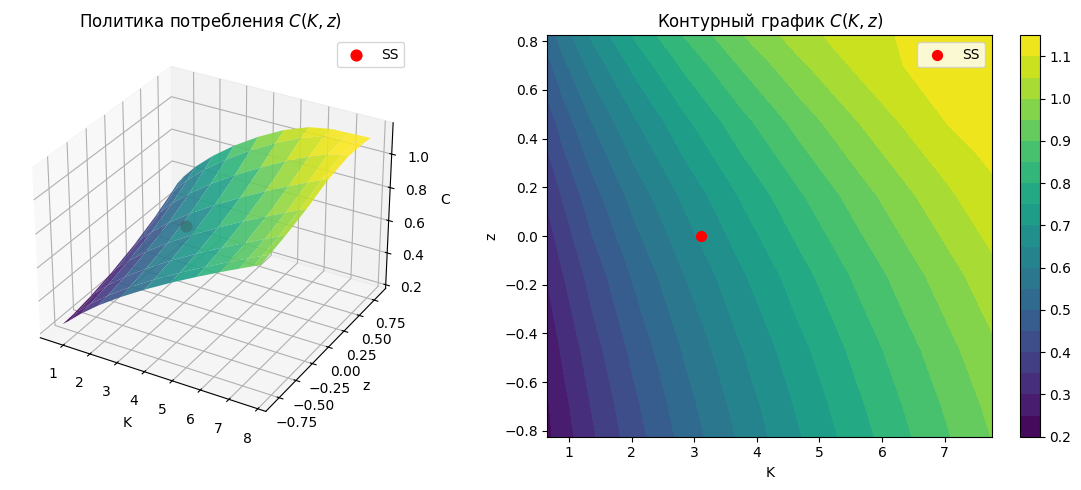

In [9]:
C_opt_grid = np.zeros((n_K, n_Z))

for i, K in enumerate(K_nodes):

    for j, z in enumerate(z_nodes):

        C_opt_grid[i, j] = C_from_theta(K, z, theta_opt)

K_mesh, z_mesh = np.meshgrid(K_nodes, z_nodes, indexing='ij')

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(K_mesh, z_mesh, C_opt_grid, cmap='viridis', edgecolor='none', alpha=0.9)

ax1.scatter([K_ss], [0.0], [C_ss], color='red', s=60, label='SS')

ax1.set_xlabel('K')

ax1.set_ylabel('z')

ax1.set_zlabel('C')

ax1.set_title('Политика потребления $C(K,z)$')

ax1.legend()

ax2 = fig.add_subplot(122)

cont = ax2.contourf(K_mesh, z_mesh, C_opt_grid, levels=20, cmap='viridis')

ax2.scatter([K_ss], [0.0], color='red', s=50, label='SS')

ax2.set_xlabel('K')

ax2.set_ylabel('z')

ax2.set_title('Контурный график $C(K,z)$')

ax2.legend()

plt.colorbar(cont, ax=ax2)

plt.tight_layout()

plt.show()

## 10. Симуляция глобального стохастического решения

In [10]:
def simulate_global_irf(theta_mat, T_sim=40, shock_size=None):
    if shock_size is None:
        shock_size = sigma

    z_path = np.zeros(T_sim)
    z_path[0] = shock_size
    for t in range(1, T_sim):
        z_path[t] = rho * z_path[t-1]

    K_path = np.zeros(T_sim + 1)
    C_path = np.zeros(T_sim)
    L_path = np.zeros(T_sim)
    Y_path = np.zeros(T_sim)
    I_path = np.zeros(T_sim)
    clipped_steps = 0

    K_path[0] = K_ss

    for t in range(T_sim):
        K_t = K_path[t]
        z_t = z_path[t]

        C_t = C_from_theta(K_t, z_t, theta_mat)
        L_t = labor_from_KC(K_t, C_t, z_t)
        if np.isnan(L_t) or (not np.isfinite(L_t)) or L_t <= 0:
            L_t = L_ss

        Y_t = production(K_t, L_t, z_t)
        I_t = Y_t - C_t
        K_next_raw = (1.0 - delta) * K_t + I_t

        K_next = np.clip(K_next_raw, K_min, K_max)
        if abs(K_next - K_next_raw) > 1e-12:
            clipped_steps += 1

        C_path[t] = C_t
        L_path[t] = L_t
        Y_path[t] = Y_t
        I_path[t] = I_t
        K_path[t+1] = K_next

    if clipped_steps > 0:
        print(f"[diag] K_next clipped on {clipped_steps} / {T_sim} steps")

    return {
        'z': z_path,
        'K': K_path[:-1],
        'C': C_path,
        'L': L_path,
        'Y': Y_path,
        'I': I_path
    }

def pct_dev(x, x_ss):
    return 100.0 * (x / x_ss - 1.0)

sim_global = simulate_global_irf(theta_opt, T_sim=40, shock_size=sigma)


## 11. Графики IRF со стационарным состоянием

Saved global IRF plot to /Users/kiri.kozlov/Desktop/diploma/dynare_images/global_chebyshev_irf.png


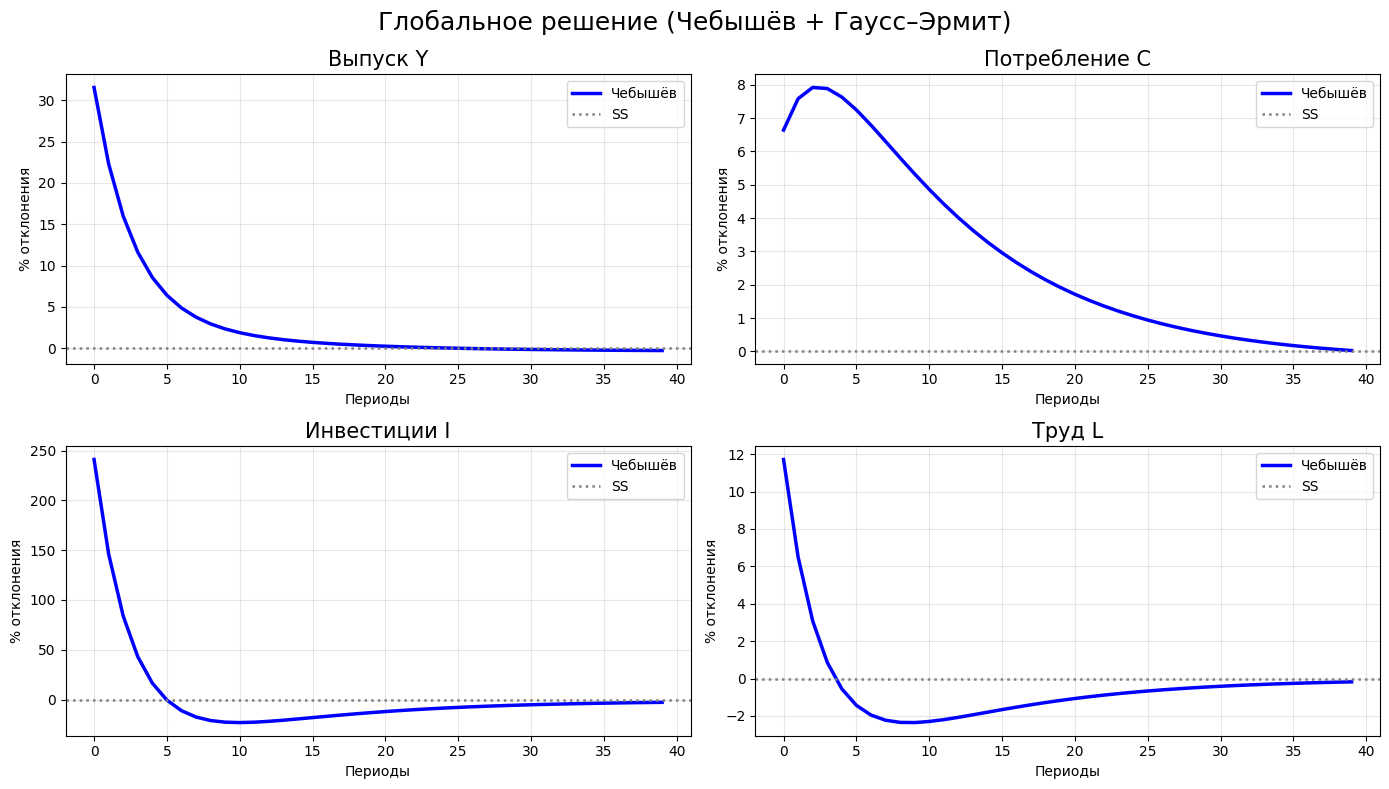

In [11]:
def plot_global_irf(sim, save_path=None):
    t = np.arange(len(sim['Y']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Глобальное решение (Чебышёв + Гаусс–Эрмит)', fontsize=18)

    series = [
        ('Y', Y_ss, 'Выпуск Y'),
        ('C', C_ss, 'Потребление C'),
        ('I', I_ss, 'Инвестиции I'),
        ('L', L_ss, 'Труд L'),
    ]

    for ax, (key, ss, title) in zip(axes.ravel(), series):
        ax.plot(t, pct_dev(sim[key], ss), color='blue', lw=2.5, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.8, label='SS')
        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved global IRF plot to {save_path}")
    plt.show()

plot_global_irf(sim_global, save_path=IMG_DIR / 'global_chebyshev_irf.png')

## 12. Как сравнивать с Dynare

In [12]:
def plot_compare_irfs(sim_global, dynare_irfs, T=40, save_path=None):
    t = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)', fontsize=18)

    comparison = [
        ('Y', Y_ss, dynare_irfs['Y'], 'Выпуск Y'),
        ('C', C_ss, dynare_irfs['C'], 'Потребление C'),
        ('I', I_ss, dynare_irfs['I'], 'Инвестиции I'),
        ('L', L_ss, dynare_irfs['L'], 'Труд L'),
    ]

    for ax, (key, ss, dyn, title) in zip(axes.ravel(), comparison):
        glob = pct_dev(sim_global[key][:T], ss)

        ax.plot(t, dyn[:T], 'r--', lw=2.5, label='Локальное (Dynare)')
        ax.plot(t, glob, 'b-', lw=2.2, label='Глобальное (Чебышёв)')
        ax.axhline(0.0, color='gray', ls=':', lw=1.6, label='SS')

        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Saved comparison plot to {save_path}")
    plt.show()

Первые 5 значений Dynare (уровневые отклонения):
Y: [0.12611575 0.08706902 0.06260206 0.04364784 0.03078004]
C: [0.03660474 0.0331935  0.03057499 0.0278274  0.02553868]
I: [0.08951101 0.05387552 0.03202707 0.01582045 0.00524136]
L: [-0.02199756 -0.016408   -0.01275044 -0.01044373 -0.00939962]


Saved comparison plot to /Users/kiri.kozlov/Desktop/diploma/dynare_images/comparison_dynare_vs_chebyshev.png


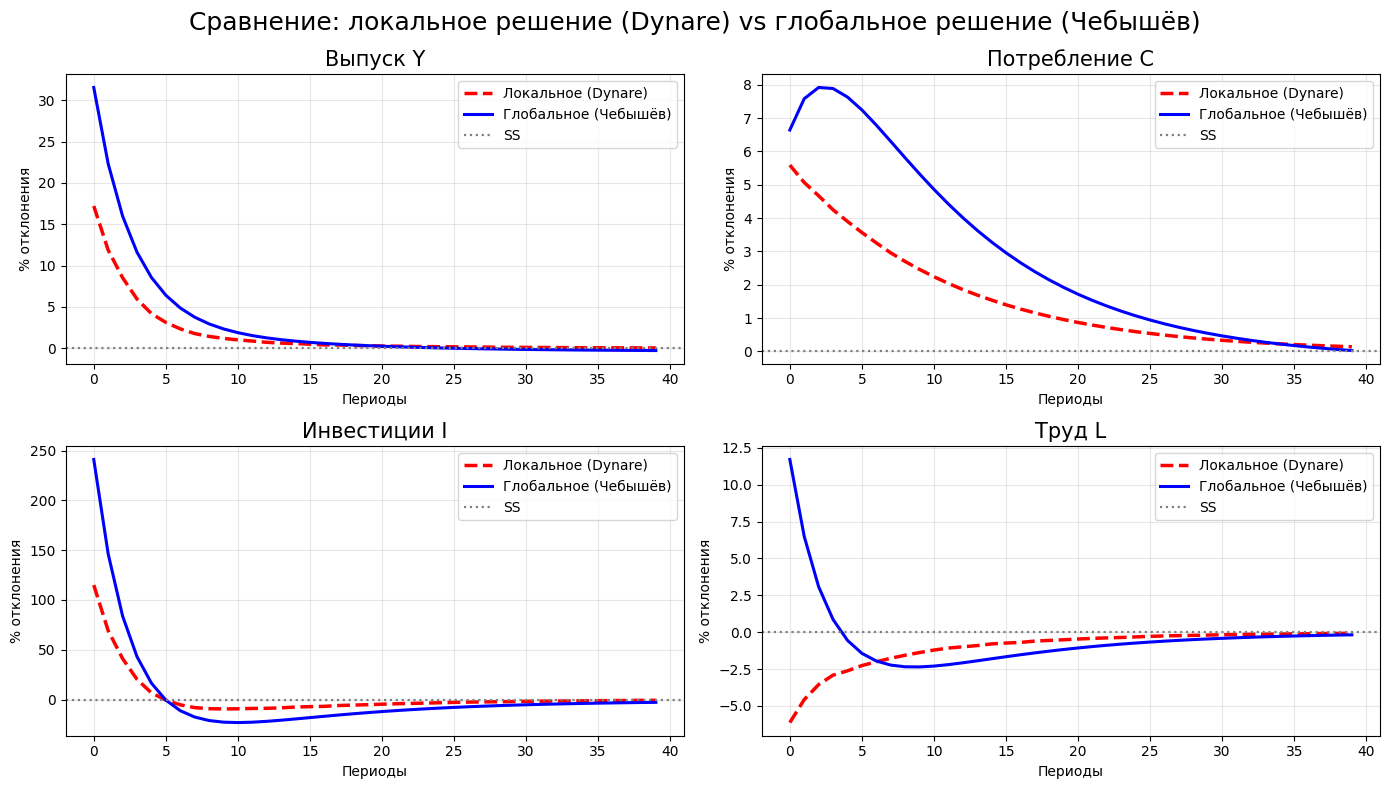

In [13]:
from scipy.io import loadmat

# Локальное решение, выгруженное из Dynare после stoch_simul (RBC.mod).
mat = loadmat(str(DYNARE_MAT))

y_dyn = np.array(mat["Y_irf"]).flatten()
c_dyn = np.array(mat["C_irf"]).flatten()
i_dyn = np.array(mat["I_irf"]).flatten()
l_dyn = np.array(mat["L_irf"]).flatten()

print("Первые 5 значений Dynare (уровневые отклонения):")
print("Y:", y_dyn[:5])
print("C:", c_dyn[:5])
print("I:", i_dyn[:5])
print("L:", l_dyn[:5])

# Dynare возвращает отклонения в уровнях относительно стационара -> переводим в %.
dynare_irfs = {
    "Y": 100.0 * y_dyn / Y_ss,
    "C": 100.0 * c_dyn / C_ss,
    "I": 100.0 * i_dyn / I_ss,
    "L": 100.0 * l_dyn / L_ss,
}

T = min(40, len(y_dyn), len(sim_global["Y"]))
plot_compare_irfs(
    sim_global,
    dynare_irfs,
    T=T,
    save_path=IMG_DIR / 'comparison_dynare_vs_chebyshev.png',
)